In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!git clone https://github.com/laukamkit/capstone_project_GroupA.git

In [ ]:
%cd capstone_project_GroupA
!git checkout main

In [ ]:
%cd src

In [ ]:
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/capstone_project_GroupA/sarimax_results'

Run from here if not using Colab.

**Do not use specific_output_dir**

In [20]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from ModelFiles.GroupAModels import SarimaxModel
from ModelFiles.ModelConfigs import SARIMAXConfig, HORIZONS
from ModelFiles.ModelPlots import *
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
%matplotlib inline

In [ ]:
models = {
    48: None,
    336: None,
    720: None
}

USE_LOG_TARGET = True
EVAL_STEP_SIZE = 48
for horizon in HORIZONS:
    sarimax_config = SARIMAXConfig(
        task_id=f"sarimax_best_model_h{horizon}",
        forecast_horizon=horizon,
        lookback_window=1440,
        target_col='LOG_TOTALDEMAND' if USE_LOG_TARGET else 'TOTALDEMAND',
        used_log_target=USE_LOG_TARGET,
        feature_cols=['demand_1_week_ago', 'demand_1_year_ago', 'TEMPERATURE','TEMP_SQUARED', 'IS_WEEKEND'],
        scale=True,
        p=[4],
        d=[0],
        q=[0],
        P=[1],
        D=[1],
        Q=[1],
        seasonality_period=48,
        enforce_stationarity=True,
        enforce_invertibility=True,
        seed=None,
        save_training_log= False,
        save_test_results= True,
        eval_step_size=EVAL_STEP_SIZE,
        debug=False
    )
    sarimax_model = SarimaxModel(sarimax_config)#, specific_output_dir=SAVE_PATH)
    sarimax_model.train_model()
    all_origins, all_timestamps, all_actuals, all_predictions, mae, rmse, mse = sarimax_model.evaluate_model(None, test_mode=True)
    models[horizon] = sarimax_model
    print("=" * 200)
    print("\n")            

Found NSW data path: C:\Users\kyim1\Desktop\capstone_project_GroupA\data\NSW
Fitting SARIMAX(4,0,0)(1,1,1,48)...
	Fitted SARIMAX(4,0,0)(1,1,1,48) - Training AIC: -4431.70 | Time taken: 147.76 seconds

	Validating SARIMAX(4,0,0)(1,1,1,48) on horizon 48 with step size 48...
	Number of rolling forecast origins: 372
		Origin 100 out of 372: Validation MAE: 300.93 MW | Validation RMSE so far: 422.52 MW
		Origin 200 out of 372: Validation MAE: 304.17 MW | Validation RMSE so far: 413.17 MW
		Origin 300 out of 372: Validation MAE: 292.17 MW | Validation RMSE so far: 402.43 MW
Rolling Forecast (h=48 steps) — Validation MAE: 346.75 MW | Validation RMSE: 501.31 MW
New best model found: order (4,0,0) | seasonal_order (1,1,1,48) - RMSE: 501.31
Best SARIMAX(4, 0, 0)(1, 1, 1, 48) - AIC: -4431.70 | Validation MSE: 251312.80 | Validation RMSE: 501.31 | Time taken: 147.76 seconds
Training complete. Saved best model and fitting progress log.

Now updating the internal state of the best model with validat

## Model Summary and Diagnostic Plots

In [35]:
with open('sarimax_summary.txt', 'w') as f:
    f.write(models[48].best_model.summary().as_text())
models[48].best_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                      LOG_TOTALDEMAND   No. Observations:                 1440
Model:             SARIMAX(4, 0, 0)x(1, 1, [1], 48)   Log Likelihood                2227.848
Date:                              Wed, 22 Apr 2026   AIC                          -4431.695
Time:                                      16:36:03   BIC                          -4368.833
Sample:                                  01-24-2018   HQIC                         -4408.189
                                       - 02-23-2018                                         
Covariance Type:                                opg                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
demand_1_week_ago     0.2221      0.024      9.283      0.000       0.175       0.269
demand_1_year_ago     0.1320      0.022      6.033      0.000       0.089       0.175
TEMPERATURE          -0.3651      0.069     -5.273      0.000      -0.501      -0.229
TEMP_SQUARED          0.2594      0.051      5.124      0.000       0.160       0.359
IS_WEEKEND            0.0029      0.007      0.392      0.695      -0.012       0.017
ar.L1                 1.3865      0.024     57.759      0.000       1.339       1.434
ar.L2                -0.1082      0.042     -2.556      0.011      -0.191      -0.025
ar.L3                -0.3231      0.042     -7.733      0.000      -0.405      -0.241
ar.L4                 0.0273      0.025      1.104      0.269      -0.021       0.076
ar.S.L48              0.1009      0.032      3.197      0.001       0.039       0.163
ma.S.L48             -0.9345      0.027    -34.594      0.000      -0.987      -0.882
sigma2                0.0022   8.68e-05     25.098      0.000       0.002       0.002
===================================================================================
Ljung-Box (L1) (Q):                   1.06   Jarque-Bera (JB):                 4.27
Prob(Q):                              0.30   Prob(JB):                         0.12
Heteroskedasticity (H):               0.87   Skew:                             0.06
Prob(H) (two-sided):                  0.12   Kurtosis:                         3.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [40]:
def plot_sarimax_residual_diagnostics(resid, horizon, save_path=None):
    fig = plt.figure(figsize=(10, 6))
    gs = fig.add_gridspec(nrows=2, ncols=2)
    ax_top = fig.add_subplot(gs[0, :])
    resid.plot(ax=ax_top, marker='o', linestyle='-', title='Residuals of SARIMAX on Training Set', markersize=4, linewidth=0.5)
    fig.suptitle(f'Horizon {horizon} Diagnostic Plots for SARIMAX Model', fontsize=16)
    ax_top.set_title('Residuals of SARIMAX on Training Set')
    ax_top.tick_params(axis='x', rotation=45, labelsize=8)
    ax_top.tick_params(axis='y', labelsize=8)
    ax_bl = fig.add_subplot(gs[1, 0])
    plot_acf(resid, lags=np.arange(1, min(len(resid), 48)), ax=ax_bl)
    ax_bl.set_title('ACF of Residuals')
    ax_br = fig.add_subplot(gs[1, 1])
    resid.plot(kind='hist', bins=30, ax=ax_br)
    ax_br.set_title('Histogram of Residuals')
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

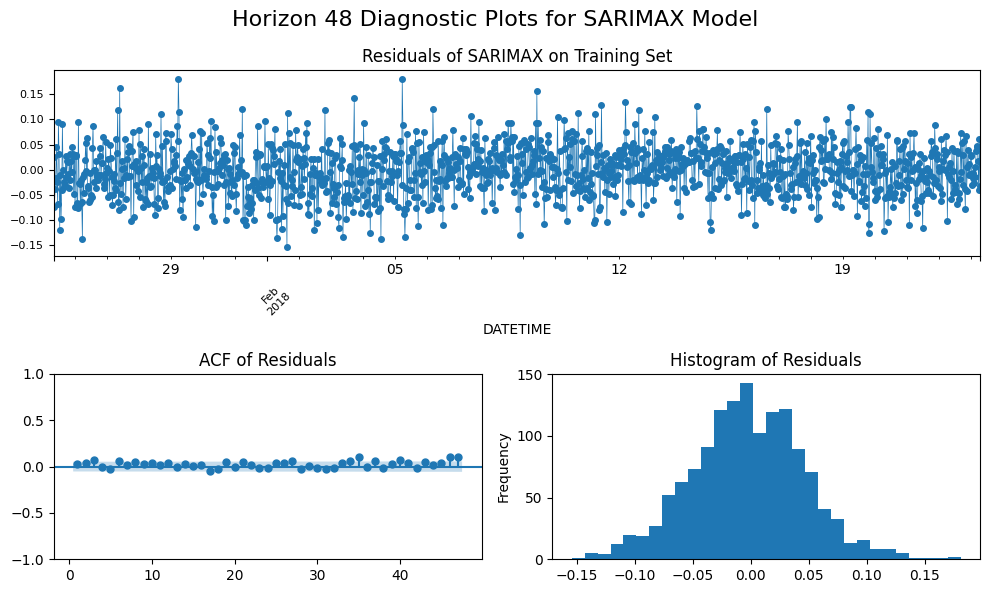

In [43]:
resid = models[48].best_model.resid[49:] # Skip the first 48 residuals to avoid unidentified lag terms
resid = pd.Series(resid)
plot_sarimax_residual_diagnostics(resid, 48, models[48].nsw_data_loader.output_dir + '/sarimax_residual_diagnostics.png')

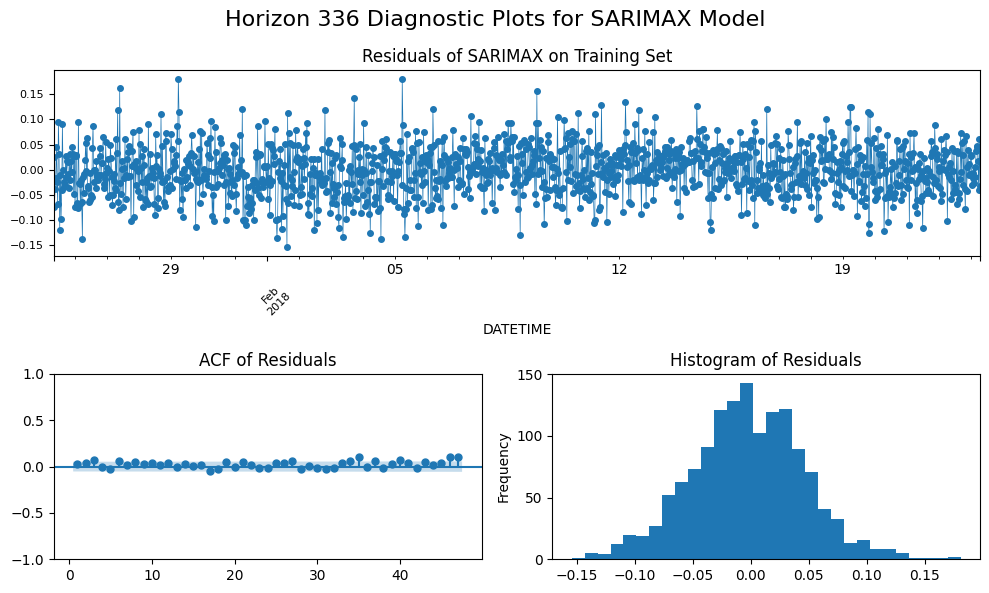

In [44]:
resid = models[336].best_model.resid[49:] # Skip the first 48 residuals to avoid unidentified lag terms
resid = pd.Series(resid)
plot_sarimax_residual_diagnostics(resid, 336)

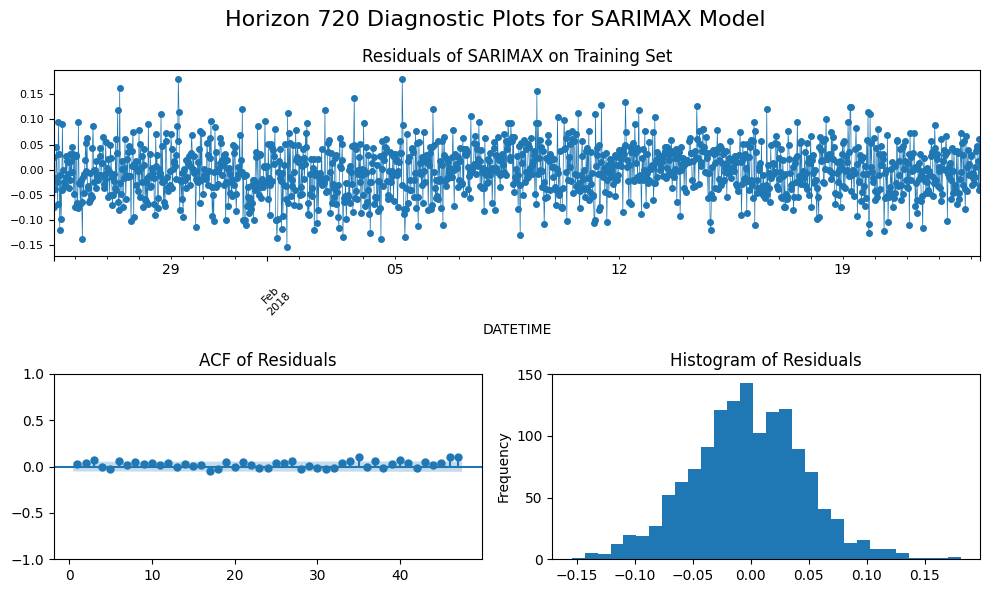

In [45]:
resid = models[720].best_model.resid[49:] # Skip the first 48 residuals to avoid unidentified lag terms
resid = pd.Series(resid)
plot_sarimax_residual_diagnostics(resid, 720)